# Eurovision: Data Preparation

This notebook takes raw Eurovision voting data from 1957 to 2026 (excluding 1956 due to the lack of individual country voting) and merges it with geographic, linguistic, colonial, and economic variables. The final output is a clean, bilateral panel dataset prepared for econometric regression analysis in Stata.

## Environment Setup

In [1]:
import pandas as pd
import numpy as np

# Used to read and combine all raw BACI data files dynamically
import glob

### Utility Functions

In [2]:
def verify_merge(df_before_count, df_after, merge_name):
    """
    Verifies that a left merge hasn't inflated the row count due to duplicate keys.

    Parameters:
        df_before_count: int, row count before merge
        df_after: DataFrame, result after merge
        merge_name: str, descriptive name for the merge (for error message)
    """
    assert len(df_after) == df_before_count, \
        f"Row count changed after {merge_name} merge - check for duplicate keys. Before: {df_before_count}, After: {len(df_after)}"
    print(f"{merge_name} merge verified — row count unchanged ({len(df_after)} rows)")

To ensure consistency across the multiple datasets, all historical and modern country names are converted to their official ISO-3 codes.

In [3]:
def iso3_conversion(dataframe, mapping_dict, from_country, to_country, drop_countries=True):
    """
    Converts country identifier columns to ISO3 codes using a provided mapping dictionary.

    Parameters:
        dataframe: pandas DataFrame
        mapping_dict: dict mapping original codes to ISO3
        from_country: str, column name for sending country
        to_country: str, column name for receiving country
        drop_countries: bool, if True filters to only countries in mapping_dict

    Returns:
        pandas DataFrame with standardised ISO3 country codes
    """
    #Drop all non Eurovision Countries
    if drop_countries:
        dataframe = dataframe[(dataframe[from_country].isin(mapping_dict.keys())) & (dataframe[to_country].isin(mapping_dict.keys()))].copy()

    #Convert to ISO3
    dataframe[from_country] = dataframe[from_country].map(mapping_dict).fillna(dataframe[from_country])
    dataframe[to_country] = dataframe[to_country].map(mapping_dict).fillna(dataframe[to_country])

    return dataframe

In [4]:
iso2_iso3_map = {
    'at': 'AUT',  # Austria
    'be': 'BEL',  # Belgium
    'dk': 'DNK',  # Denmark
    'fr': 'FRA',  # France
    'de': 'DEU',  # Germany
    'it': 'ITA',  # Italy
    'lu': 'LUX',  # Luxembourg
    'nl': 'NLD',  # Netherlands
    'ch': 'CHE',  # Switzerland
    'gb': 'GBR',  # United Kingdom
    'se': 'SWE',  # Sweden
    'mc': 'MCO',  # Monaco
    'no': 'NOR',  # Norway
    'fi': 'FIN',  # Finland
    'es': 'ESP',  # Spain
    'pt': 'PRT',  # Portugal
    'ie': 'IRL',  # Ireland
    'mt': 'MLT',  # Malta
    'il': 'ISR',  # Israel
    'gr': 'GRC',  # Greece
    'tr': 'TUR',  # Turkey
    'ma': 'MAR',  # Morocco
    'cy': 'CYP',  # Cyprus
    'is': 'ISL',  # Iceland
    'ba': 'BIH',  # Bosnia and Herzegovina
    'hr': 'HRV',  # Croatia
    'si': 'SVN',  # Slovenia
    'ee': 'EST',  # Estonia
    'hu': 'HUN',  # Hungary
    'lt': 'LTU',  # Lithuania
    'pl': 'POL',  # Poland
    'ro': 'ROU',  # Romania
    'ru': 'RUS',  # Russia
    'sk': 'SVK',  # Slovakia
    'mk': 'MKD',  # North Macedonia
    'lv': 'LVA',  # Latvia
    'ua': 'UKR',  # Ukraine
    'al': 'ALB',  # Albania
    'ad': 'AND',  # Andorra
    'by': 'BLR',  # Belarus
    'bg': 'BGR',  # Bulgaria
    'md': 'MDA',  # Moldova
    'am': 'ARM',  # Armenia
    'cz': 'CZE',  # Czechia
    'ge': 'GEO',  # Georgia
    'me': 'MNE',  # Montenegro
    'rs': 'SRB',  # Serbia
    'az': 'AZE',  # Azerbaijan
    'sm': 'SMR',  # San Marino
    'au': 'AUS',  # Australia
    'yu': 'YUG',  # Yugoslavia
    'cs': 'SCG'  # Serbia and Montenegro
}

In [5]:
imf_to_iso3 = {
    'Albania': 'ALB',
    'Andorra': 'AND',
    'Armenia': 'ARM',
    'Australia': 'AUS',
    'Austria': 'AUT',
    'Azerbaijan': 'AZE',
    'Belarus': 'BLR',
    'Belgium': 'BEL',
    'Bosnia and Herzegovina': 'BIH',
    'Bulgaria': 'BGR',
    'Croatia': 'HRV',
    'Cyprus': 'CYP',
    'Czech Republic': 'CZE',
    'Denmark': 'DNK',
    'Estonia': 'EST',
    'Finland': 'FIN',
    'France': 'FRA',
    'Georgia': 'GEO',
    'Germany': 'DEU',
    'Greece': 'GRC',
    'Hungary': 'HUN',
    'Iceland': 'ISL',
    'Ireland': 'IRL',
    'Israel': 'ISR',
    'Italy': 'ITA',
    'Latvia': 'LVA',
    'Lithuania': 'LTU',
    'Luxembourg': 'LUX',
    'Malta': 'MLT',
    'Moldova': 'MDA',
    'Montenegro': 'MNE',
    'Morocco': 'MAR',
    'Netherlands': 'NLD',
    'North Macedonia': 'MKD',
    'Norway': 'NOR',
    'Poland': 'POL',
    'Portugal': 'PRT',
    'Romania': 'ROU',
    'Russian Federation': 'RUS',
    'San Marino': 'SMR',
    'Serbia': 'SRB',
    'Slovak Republic': 'SVK',
    'Slovenia': 'SVN',
    'Spain': 'ESP',
    'Sweden': 'SWE',
    'Switzerland': 'CHE',
    'Türkiye, Republic of': 'TUR',
    'Ukraine': 'UKR',
    'United Kingdom': 'GBR'
}


In [6]:
#Map of UN location codes to ISO3 codes
un_to_iso3 = {
    40: 'AUT',  # Austria
    56: 'BEL',  # Belgium
    208: 'DNK',  # Denmark
    250: 'FRA',  # France
    276: 'DEU',  # Germany
    380: 'ITA',  # Italy
    442: 'LUX',  # Luxembourg
    528: 'NLD',  # Netherlands
    756: 'CHE',  # Switzerland
    826: 'GBR',  # United Kingdom
    752: 'SWE',  # Sweden
    492: 'MCO',  # Monaco
    578: 'NOR',  # Norway
    246: 'FIN',  # Finland
    724: 'ESP',  # Spain
    620: 'PRT',  # Portugal
    372: 'IRL',  # Ireland
    470: 'MLT',  # Malta
    376: 'ISR',  # Israel
    300: 'GRC',  # Greece
    792: 'TUR',  # Türkiye
    504: 'MAR',  # Morocco
    196: 'CYP',  # Cyprus
    352: 'ISL',  # Iceland
    70: 'BIH',  # Bosnia and Herzegovina
    191: 'HRV',  # Croatia
    705: 'SVN',  # Slovenia
    233: 'EST',  # Estonia
    348: 'HUN',  # Hungary
    440: 'LTU',  # Lithuania
    616: 'POL',  # Poland
    642: 'ROU',  # Romania
    643: 'RUS',  # Russian Federation
    703: 'SVK',  # Slovakia
    807: 'MKD',  # North Macedonia
    428: 'LVA',  # Latvia
    804: 'UKR',  # Ukraine
    8: 'ALB',  # Albania
    20: 'AND',  # Andorra
    112: 'BLR',  # Belarus
    100: 'BGR',  # Bulgaria
    498: 'MDA',  # Moldova
    51: 'ARM',  # Armenia
    203: 'CZE',  # Czechia
    268: 'GEO',  # Georgia
    499: 'MNE',  # Montenegro
    688: 'SRB',  # Serbia
    31: 'AZE',  # Azerbaijan
    674: 'SMR',  # San Marino
    36: 'AUS',  # Australia
}

In [7]:
eurostat_to_iso3 = {
    'AL': 'ALB', 'AD': 'AND', 'AM': 'ARM', 'AU': 'AUS',
    'AT': 'AUT', 'AZ': 'AZE', 'BE': 'BEL', 'BA': 'BIH',
    'BG': 'BGR', 'BY': 'BLR', 'CH': 'CHE', 'CY': 'CYP',
    'CZ': 'CZE', 'DE': 'DEU', 'DK': 'DNK', 'ES': 'ESP',
    'EE': 'EST', 'FI': 'FIN', 'FR': 'FRA', 'UK': 'GBR',
    'GE': 'GEO', 'EL': 'GRC', 'HR': 'HRV', 'HU': 'HUN',
    'IE': 'IRL', 'IS': 'ISL', 'IL': 'ISR', 'IT': 'ITA',
    'LT': 'LTU', 'LU': 'LUX', 'LV': 'LVA', 'MA': 'MAR',
    'MC': 'MCO', 'MD': 'MDA', 'MK': 'MKD', 'MT': 'MLT',
    'ME': 'MNE', 'NL': 'NLD', 'NO': 'NOR', 'PL': 'POL',
    'PT': 'PRT', 'RO': 'ROU', 'RU': 'RUS', 'SM': 'SMR',
    'RS': 'SRB', 'SK': 'SVK', 'SI': 'SVN', 'SE': 'SWE',
    'TR': 'TUR', 'UA': 'UKR'
}

## Eurovision Voting Data

Spijkervet's dataset containing Eurovision voting history from 1957 to 2023 is combined with a manually compiled dataset of voting results from 2024 to 2026 to create a comprehensive bilateral voting panel.

In [8]:
vote_df_1957_2023 = pd.read_csv('data/raw/eurovision/votes.csv')
vote_df_2024_2026 = pd.read_csv('data/raw/eurovision/votes-2024-2026.csv')

In [9]:
#Drop all semi-final results and rest of the world vote
vote_df_1957_2023 = vote_df_1957_2023[
    (vote_df_1957_2023['round'] == 'final') & (vote_df_1957_2023['from_country_id'] != 'wld')]

#Dropping redundant columns
vote_df_1957_2023 = vote_df_1957_2023.drop(labels=['from_country', 'to_country'], axis=1)

In [10]:
#Replace ISO2 codes with ISO3 - All countries competing within the dataset have competed in eurovision so drop_countries is set to false
vote_df_1957_2023 = iso3_conversion(vote_df_1957_2023, iso2_iso3_map, 'from_country_id', 'to_country_id', drop_countries=False)

In [11]:
#Merge both dataframes to create comprehensive voting dataset with records from 1957-2026
vote_df = pd.concat([vote_df_1957_2023, vote_df_2024_2026])

In [12]:
#Drop self-voting rows
vote_df = vote_df[vote_df['from_country_id'] != vote_df['to_country_id']]

#Drop round column
vote_df = vote_df.drop(labels=['round'], axis=1)

The winner of the Eurovision Song Contest is decided by a positional voting system. This system has undergone several revisions since the contest's conception in 1956 such that the maximum points a country can receive from another varies from 3-24 depending on year.

We therefore normalise the points received by a country by dividing the points received by the maximum points available to be given that year - such that votes are given on a scale of 0-1.

In [13]:
#Create list containing different voting regime periods
conditions = [
    (vote_df['year'] <= 1961) | ((vote_df['year'] >= 1967) & (vote_df['year'] <= 1974)),
    vote_df['year'] == 1962,
    vote_df['year'] == 1963,
    (vote_df['year'] >= 1964) & (vote_df['year'] <= 1966),
    (vote_df['year'] >= 1975) & (vote_df['year'] <= 2015),
    vote_df['year'] >= 2016
]
#Create list with max points in each voting regime period
max_points = [10, 3, 5, 9, 12, 24]

#Create normalised voting column (total points are on a scale of 0-1)
vote_df['norm_points'] = np.select(conditions, [vote_df['total_points'] / m for m in max_points], default=np.nan)

#Stores maximum points available in each voting era used in normalisation
vote_df['voting_regime'] = np.select(conditions, max_points, default=np.nan)

In [14]:
#Create pair-id column to identify country matches
vote_df['pair_id'] = vote_df['from_country_id'] + '-' + vote_df['to_country_id']

#Create numeric country pair identifier
vote_df['numeric_id'] = pd.factorize(vote_df['pair_id'])[0]

## Geographic, linguistic and colonial Data

CEPII's GeoDist dataset is used to provide geographical variables.
This includes...<br> <br>
contig: whether the two countries are contiguous <br>
comlang_off: whether the two countries share an official language <br>
comlang_ethno: whether a language is spoken by at least 9% of the population in both countries <br>
colony: whether the two countries ever had a colonial link <br>
comcol: whether the two countries have had a common colonizer after 1945 (this tends to capture shared imperial legacy rather than traditional colonialism in our dataset) <br>
col45: whether the two countries have had a colonial relationship since 1945 <br>
curcol: whether the two countries are currently in a colonial relationship <br>
smctry: whether the two countries were the same country <br>
distw: weighted bilateral distance between countries <br> <br>

CEPII's GeoDist dataset also contains the distwces variable which uses θ = -1 in the weighted distance formula, corresponding to the coefficient typically estimated in gravity models. distw (θ = 1) is preferred here as the simpler population-weighted measure is more appropriate for cultural proximity than trade cost estimation.
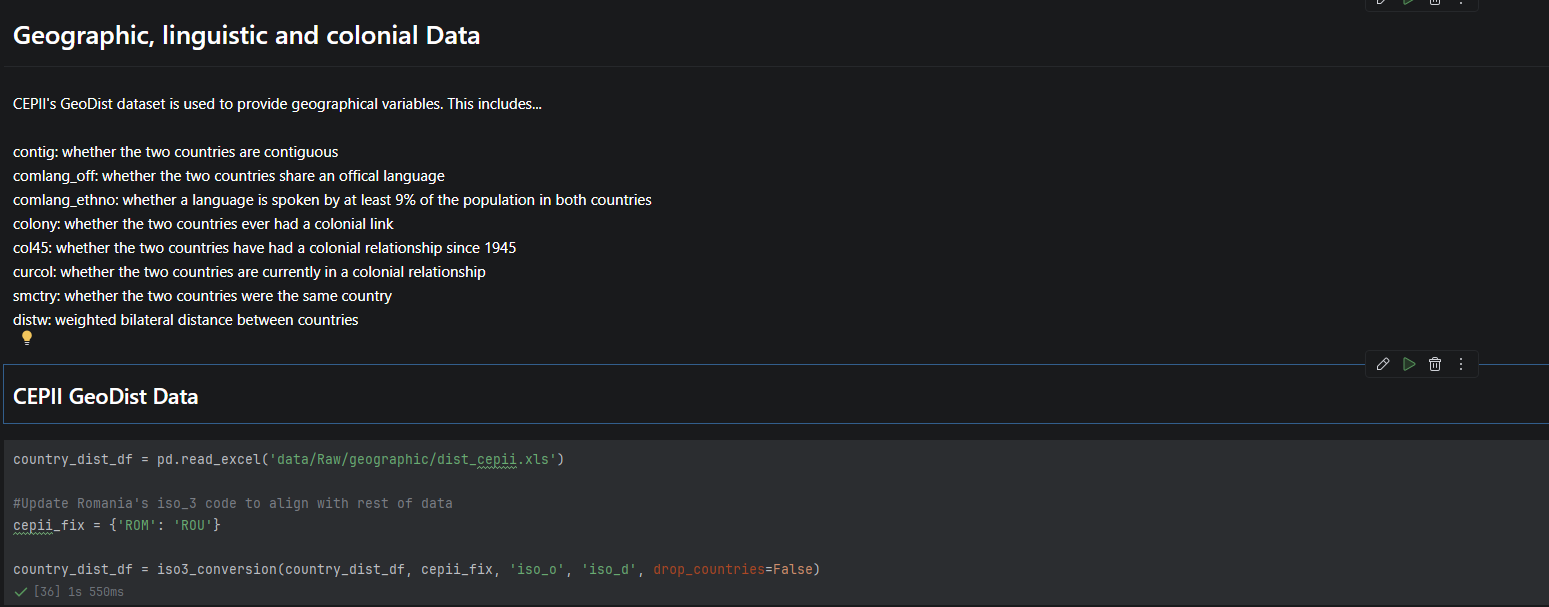

### CEPII GeoDist Data

In [15]:
#Note pre merge count
pre_merge_count = len(vote_df)

#Load GeoData
country_dist_df = pd.read_excel('data/raw/geographic/dist_cepii.xls')

#Update Romania's iso_3 code to align with rest of data
cepii_fix = {'ROM': 'ROU'}

country_dist_df = iso3_conversion(country_dist_df, cepii_fix, 'iso_o', 'iso_d', drop_countries=False)

In [16]:
country_dist_df['pair_id'] = country_dist_df['iso_o'] + '-' + country_dist_df['iso_d']

In [17]:
#Drop irrelevant columns (e.g. country origin and target) and other distance measures
country_dist_df = country_dist_df.drop(labels=['iso_o', 'iso_d', 'dist', 'distcap', 'distwces'], axis=1)

In [18]:
# Add variables to vote_df
# Merging on pair_id rather than individual country codes is appropriate...
# GeoDist is undirected — distance between i and j is identical to distance between j and i, so a single pair-level identifier is sufficient.

vote_df = vote_df.merge(country_dist_df, on='pair_id', how='left')

#Convert weighted distance to numeric datatype
vote_df['distw'] = pd.to_numeric(vote_df['distw'], errors='coerce')

verify_merge(pre_merge_count, vote_df, 'GeoDist')

GeoDist merge verified — row count unchanged (38781 rows)


### Geopolitical Features

A manually compiled dataset is used to provide geopolitical variables. These include... <br><br>
former_soviet: whether both countries are former Soviet countries. <br>
former_yugoslav	: whether both countries were formerly part of Yugoslavia <br>
scandinavian: whether both countries are Scandinavian <br>
balkan: whether both countries are Balkan <br>
eu_membership: whether both countries are considered part of the European Union (the UK is noted as having left in 2016 as that is arguably a more accurate reflection of when the cultural ramifications of the referendum were felt rather than 2020). <br>



In [19]:
#Note pre merge count
pre_merge_count = len(vote_df)

#Load dataset
cultural_df = pd.read_excel('data/raw/blocs/Euro Dummies.xlsx')

# add_suffix ensures column names don't conflict when merging sender and receiver dummies separately
#Add cultural dummies of vote senders
vote_df = pd.merge(vote_df, cultural_df.add_suffix('_from_country'), left_on='from_country_id', right_on='iso3_from_country', how='left')

#Add cultural dummies of vote receivers
vote_df = pd.merge(vote_df, cultural_df.add_suffix('_to_country'), left_on='to_country_id', right_on='iso3_to_country', how='left')

vote_df = vote_df.drop(labels=['iso3_from_country','iso3_to_country'], axis=1)

In [20]:
#Add cultural dummy variables for country pair
vote_df['former_soviet'] = vote_df['former_soviet_from_country'] & vote_df['former_soviet_to_country']
vote_df['former_yugoslav'] = vote_df['former_yugoslav_from_country'] & vote_df['former_yugoslav_to_country']
vote_df['scandinavian'] = vote_df['scandinavian_from_country'] & vote_df['scandinavian_to_country']
vote_df['balkan'] = vote_df['balkan_from_country'] & vote_df['balkan_to_country']


In [21]:
# A country is considered EU member if:
# 1. The year is on or after their accession year
# 2. They have not yet left (exit year is NaN or in the future)

#Add EU membership dummy variable
from_in_eu = (vote_df['eu_accession_year_from_country'] <= vote_df['year']) & ((vote_df['eu_exit_year_from_country'] > vote_df['year']) | (vote_df['eu_exit_year_from_country'].isna()))
to_in_eu = (vote_df['eu_accession_year_to_country'] <= vote_df['year']) & ((vote_df['eu_exit_year_to_country'] > vote_df['year']) | (vote_df['eu_exit_year_to_country'].isna()))

#Drop intermediate columns eu_accession_year_from_country/eu_exit_year_from_country
vote_df = vote_df.drop(labels=['eu_accession_year_from_country', 'eu_accession_year_to_country', 'eu_exit_year_from_country', 'eu_exit_year_to_country'], axis=1)

#Convert Boolean to Int for dummy variable
vote_df['eu_membership'] = (from_in_eu & to_in_eu).astype(int)

In [22]:
verify_merge(pre_merge_count, vote_df, 'GeoPol')

GeoPol merge verified — row count unchanged (38781 rows)


## GDP Data

The IMF World Economic Outlook is used to provide economic variables. This includes two datasets:<br><br>
Country GDP (Billions of U.S. dollars) <br>
Country GDP per capita (U.S. dollars per capita) data. <br><br>

From this two further variables are constructed:<br> <br>The natural logarithm of both variables, given the large variation in GDP data driven by the size of G7 countries relative to microstates.<br> A GDP similarity index ranging from 0 to 1, where 1 indicates two countries are identical in economic size and 0 indicates one economy completely dominates the other. This is calculated using log GDP to capture proportional rather than absolute differences in economic size.

In [23]:
#Note pre merge count
pre_merge_count = len(vote_df)

#Load GDP data
GDP_df = pd.read_excel('data/raw/gdp/imf-GDP.xlsx')

# Drop row 0 (empty header row), rows 50-51 (empty tail row)
GDP_df = GDP_df.drop(labels=[0, 50, 51])
GDP_df = GDP_df.rename(mapper={'GDP, current prices (Billions of U.S. dollars)': 'Country'}, axis=1)
GDP_df = GDP_df.drop(labels=['Estimates start after'], axis=1)
GDP_df = GDP_df.melt(id_vars=['Country'], var_name='year', value_name='gdp_usd')

In [24]:
#Load GDP per capita data
GDP_per_capita_df = pd.read_excel('data/raw/gdp/imf-gdp-per-capita.xlsx')
GDP_per_capita_df = GDP_per_capita_df.drop(labels=[0, 50, 51])
GDP_per_capita_df  = GDP_per_capita_df.rename(mapper={'GDP per capita, current prices\n (U.S. dollars per capita)' : 'Country'}, axis=1)
GDP_per_capita_df = GDP_per_capita_df.drop(labels=['Estimates start after'], axis=1)
GDP_per_capita_df = GDP_per_capita_df.melt(id_vars=['Country'], var_name='year', value_name='gdp_pc_usd')

In [25]:
#Insert GDP per capita data into GDP dataframe to create one comprehensive dataset
GDP_df['gdp_pc_usd'] = GDP_per_capita_df['gdp_pc_usd']

GDP_df[['gdp_usd', 'gdp_pc_usd']] = GDP_df[['gdp_usd', 'gdp_pc_usd']].replace('no data', np.nan)

In [26]:
#Convert country labels to ISO3 codes
GDP_df['Country'] = GDP_df['Country'].map(imf_to_iso3)

#Convert to numeric data types
GDP_df['gdp_usd'] = pd.to_numeric(GDP_df['gdp_usd'], errors='coerce')
GDP_df['gdp_pc_usd'] = pd.to_numeric(GDP_df['gdp_pc_usd'], errors='coerce')
GDP_df['year'] = pd.to_numeric(GDP_df['year'])

In [27]:
#Generate log of gdp and log of gdp_per_capita
GDP_df['log_gdp_usd'] = np.log(GDP_df['gdp_usd'])
GDP_df['log_gdp_pc_usd'] = np.log(GDP_df['gdp_pc_usd'])

In [28]:
#Add GDP data of the vote sender to panel dataset
vote_df = pd.merge(vote_df, GDP_df, left_on=['from_country_id', 'year'], right_on=['Country', 'year'], how='left')

#Drop duplicate country column
vote_df = vote_df.drop(labels=['Country'], axis=1)

#Rename gdp columns to indicate gdp is that of the vote sender
vote_df = vote_df.rename(
    mapper={'gdp_usd': 'from_gdp_usd', 'gdp_pc_usd': 'from_gdp_pc_usd', 'log_gdp_usd': 'from_log_gdp_usd',
            'log_gdp_pc_usd': 'from_log_gdp_pc_usd'}, axis=1)

In [29]:
#Add GDP of the vote receiver to panel dataset
vote_df = pd.merge(vote_df, GDP_df, left_on=['to_country_id', 'year'], right_on=['Country', 'year'], how='left')

#Drop duplicate country column
vote_df = vote_df.drop(labels=['Country'], axis=1)

#Rename gdp columns to indicate gdp is that of the vote receiver
vote_df = vote_df.rename(
    mapper={'gdp_usd': 'to_gdp_usd', 'gdp_pc_usd': 'to_gdp_pc_usd', 'log_gdp_usd': 'to_log_gdp_usd',
            'log_gdp_pc_usd': 'to_log_gdp_pc_usd'}, axis=1)

In [30]:
#Calculate the GDP similarity index
vote_df['gdp_similarity'] = 1 - (np.abs(vote_df['from_log_gdp_usd'] - vote_df['to_log_gdp_usd']) / (
            np.abs(vote_df['from_log_gdp_usd']) + np.abs(vote_df['to_log_gdp_usd'])))

In [31]:
verify_merge(pre_merge_count, vote_df, 'GDP')

GDP merge verified — row count unchanged (38781 rows)


## Migration Data

The UN Department of Economic Social Affairs's International Migrant Stock is utilised to provide migration data. To fill in gaps, eurostat data on migration and asylum is utilised as a complement.

### UN DESA Migration Data

UN DESA publishes estimates of international migrant stocks by origin and destination country for 233 countries and areas, at five-year intervals from 1990 to 2024. 2024 figures represent extrapolations of estimates published in the 2020 edition of the dataset. Linear interpolation is utilised to fill annual values between 5-year points within each country pair

In [32]:
#Note pre merge count
pre_merge_count = len(vote_df)

migration_df = pd.read_excel(io='data/raw/migration/undesa_pd_2024_ims_stock_by_sex_destination_and_origin.xlsx',
                             sheet_name='Table 1', skiprows=10)

In [33]:
migration_df = iso3_conversion(migration_df, un_to_iso3, 'Location code of destination', 'Location code of origin')

# Rename ISO3 code columns to descriptive names for readability
migration_df = migration_df.rename({'Location code of origin': 'Country of origin', 'Location code of destination': 'Country of destination'}, axis=1)

In [34]:
#Drop variables not relevant to our regression (i.e. .1 .2 suffix columns representing international male and female migrant stock respectively)
migration_df = migration_df.drop(labels=[
    'Coverage', 'Data type', 'Index', 'Region, development group, country or area of destination',
    'Region, development group, country or area of origin',
    '1990.1', '1995.1', '2000.1', '2005.1', '2010.1', '2015.1', '2020.1', '2024.1',
    '1990.2', '1995.2', '2000.2', '2005.2', '2010.2', '2015.2', '2020.2', '2024.2'
], axis=1)

In [35]:
migration_df = pd.melt(migration_df, id_vars=['Country of origin', 'Country of destination'],
                       value_vars=[1990, 1995, 2000, 2005, 2010, 2015, 2020, 2024], value_name='migrant_stock',
                       var_name='year')

In [36]:
#Convert Year to numeric data type
migration_df['year'] = pd.to_numeric(migration_df['year'])

#Interpolate missing values

#Set multi-index
migration_df = migration_df.set_index(['Country of origin', 'Country of destination', 'year'])

#Create a complete year index from 1995-2024 (where we are able to interpolate values)
year_list = list(range(1990, 2025))
year_country_pairs = pd.MultiIndex.from_product([migration_df.index.get_level_values('Country of origin').unique(), migration_df.index.get_level_values('Country of destination').unique() ,year_list], names=['Country of origin', 'Country of destination', 'year'])

#Reindex the dataframe to include full year index
migration_df = migration_df.reindex(year_country_pairs)

#Reindexing artificially creates same-country pairs.
#Drop same-country pairs
migration_df = migration_df[~(migration_df.index.get_level_values('Country of origin') == migration_df.index.get_level_values('Country of destination'))]

#Interpolate to fill annual values between report points
migration_df = migration_df.groupby(['Country of origin', 'Country of destination']).transform(lambda x: x.interpolate(method='linear'))

#Reset index to prepare for merge
migration_df = migration_df.reset_index()

Note: migration is merged such that the country of origin maps to the vote recipient (to_country_id) and country of destination maps to the vote sender (from_country_id). This captures the diaspora hypothesis, immigrants vote for their home country.

In [37]:
#Merge migration_df with vote_df
vote_df = pd.merge(vote_df, migration_df, left_on=['from_country_id', 'to_country_id', 'year'], right_on=['Country of destination', 'Country of origin', 'year'], how='left')

vote_df['migration_source'] = np.where(vote_df['migrant_stock'].notna(), 'UN_DESA', None)

In [38]:
verify_merge(pre_merge_count, vote_df, 'UN Migration')

UN Migration merge verified — row count unchanged (38781 rows)


### EUROSTAT Migration Data

Eurostat's Migration and Asylum database is used to supplement UN DESA migration data where bilateral coverage is incomplete. Eurostat provides annual estimates of international migrants by country of birth for European destination countries, covering 2008 to 2024. <br> <br>
Where individual annual observations are missing within the 2008-2024 period, linear interpolation is used to fill gaps within each country pair. <br><br> Within the final output country pairs where UN DESA data already exists are preserved. Eurostat values are only used to fill observations where migrant_stock remains missing after the UN DESA merge. <br> <br>
Note: Eurostat destination coverage is limited to European and EEA countries. Non-European Eurovision participants (Australia, Israel, Azerbaijan, Armenia, Georgia) will not have their inbound migration covered by this source.

In [39]:
#Note pre merge count
pre_merge_count = len(vote_df)

#Load data
eurostat_df = pd.read_csv('data/raw/migration/estat_migr_imm3ctb.tsv', sep='\t')

In [40]:
#Characteristic variables are combined in a single tab, separated by commas. These are split to handle these specific variables
eurostat_df[['freq', 'age', 'agedef', 'c_birth', 'unit', 'sex', 'geo']] = eurostat_df[
    r'freq,age,agedef,c_birth,unit,sex,geo\TIME_PERIOD'].str.split(pat=',', expand=True)

#Filter to contain data on all sexes, and all age groups
eurostat_df = eurostat_df[
    (eurostat_df['sex'] == 'T') & (eurostat_df['age'] == 'TOTAL') & (eurostat_df['agedef'] == 'COMPLET')]

#Keep only columns of interest
eurostat_df = eurostat_df.drop(
    labels=[r'freq,age,agedef,c_birth,unit,sex,geo\TIME_PERIOD', 'freq', 'age', 'agedef', 'unit', 'sex'], axis=1)

In [41]:
eurostat_df = iso3_conversion(eurostat_df, eurostat_to_iso3, 'c_birth', 'geo')

In [42]:
#Get rid of all observation flags to leave the numerical value only
#Trailing spaces after years are intentional to match tsv file
observation_years = ['2008 ', '2009 ', '2010 ', '2011 ', '2012 ', '2013 ', '2014 ', '2015 ',
       '2016 ', '2017 ', '2018 ', '2019 ', '2020 ', '2021 ', '2022 ', '2023 ',
       '2024 ']
eurostat_df[observation_years] = eurostat_df[observation_years].replace(r'[a-zA-Z\s:]', '', regex=True)

#Convert to numeric
eurostat_df[observation_years] = eurostat_df[observation_years].apply(pd.to_numeric, errors='coerce')

In [43]:
#Melt to long format
eurostat_df = pd.melt(eurostat_df, id_vars=['c_birth', 'geo'], value_vars=observation_years, value_name='migrant_stock', var_name='year')

#Convert year to numeric
eurostat_df['year'] = eurostat_df['year'].apply(pd.to_numeric, errors='coerce')

In [44]:
# Unlike UN Desa no reindexing is needed - Eurostat is already annual so there are no 5-year gaps to fill

#Set multi-index
eurostat_df = eurostat_df.set_index(['c_birth', 'geo', 'year'])

#Interpolate missing values
eurostat_df = eurostat_df.groupby(['c_birth', 'geo']).transform(
    lambda x: x.interpolate(method='linear'))

# Reset index to prepare for merge onto vote_df
eurostat_df = eurostat_df.reset_index()

In [45]:
#Create a copy of voting_df with eurostat migrant stock data
eurostat_merge_temp = pd.merge(vote_df, eurostat_df, left_on=['from_country_id', 'to_country_id', 'year'], right_on=['geo', 'c_birth', 'year'], how='left', suffixes=('', '_eurostat'))

# Only fill rows where migrant_stock is NaN - preserves UN DESA values where they exist
vote_df['migrant_stock'] = vote_df['migrant_stock'].fillna(eurostat_merge_temp['migrant_stock_eurostat'])

#Note data source
vote_df['migration_source'] = np.where(
    (vote_df['migration_source'].isna()) & (vote_df['migrant_stock'].notna()),
    'Eurostat',
    vote_df['migration_source']
)

vote_df['migration_source'] = vote_df['migration_source'].fillna('missing')

vote_df = vote_df.drop(labels=['Country of origin', 'Country of destination'], axis=1)

In [46]:
verify_merge(pre_merge_count, vote_df, 'Euro Migration')

Euro Migration merge verified — row count unchanged (38781 rows)


### Migration Intensity

Raw migrant stock figures capture the absolute number of immigrants from a given country, but do not account for the size of the voting country's population. A large migrant stock in Germany means something very different to the same stock in Luxembourg. <br><br>
To address this, we construct a migration intensity measure, the migrant stock from the recipient country as a share of the voting country's total population. This captures the relative influence of the diaspora community on the voting country's televote. <br><br>
Population data is sourced from the World Bank (indicator SP.POP.TOTL), providing annual estimates for all countries from 1960 to 2023.

In [47]:
#Note pre merge count
pre_merge_count = len(vote_df)

# First 4 rows are skipped - these are title rows showing the data source and last updated date
population_df = pd.read_csv('data/raw/migration/API_SP.POP.TOTL_DS2_en_csv_v2_267553/API_SP.POP.TOTL_DS2_en_csv_v2_267553.csv',
                            skiprows=4)

In [48]:
# Drop non eurovision countries
population_df = population_df[population_df['Country Code'].isin(iso2_iso3_map.values())]

In [49]:
population_df = population_df.melt(id_vars='Country Code',
                                   value_vars=[str(year) for year in range(1960, 2026)], var_name='year',
                                   value_name='voting_country_population')

population_df['year'] = pd.to_numeric(population_df['year'])

In [50]:
vote_df = pd.merge(vote_df, population_df, left_on=['year', 'from_country_id'], right_on=['year', 'Country Code'],
                   how='left')

# Drop redundant country code column after merge
vote_df = vote_df.drop(labels=['Country Code'], axis=1)

In [51]:
# Migration intensity = migrants from recipient country / voting country population
# Captures diaspora share of voting country population rather than absolute stock
vote_df['migration_intensity'] = vote_df['migrant_stock'] / vote_df['voting_country_population']

In [52]:
verify_merge(pre_merge_count, vote_df, 'Migration Intensity')

Migration Intensity merge verified — row count unchanged (38781 rows)


## Bilateral Trade Data

Bilateral trade data is sourced from CEPII's BACI (Base pour l'Analyse du Commerce International) database, which provides harmonised international trade data at the product level using the Harmonized System 6-digit (HS6) nomenclature. Values are reported in thousands of current USD. <br><br>
As we are interested in total bilateral trade rather than product-level flows, trade values are aggregated across all products for each country pair and year. To construct bilateral trade — the total trade flowing in both directions between two countries — exports from i to j are summed with exports from j to i. <br><br>
Two further trade measures are constructed:<br><br>

log_trade_bilateral — the natural log of total bilateral trade in billions of USD <br>
trade_openness — bilateral trade as a share of combined GDP, normalising for country size. A large economy like Germany trades more in absolute terms with everyone — trade openness captures genuine economic integration rather than just scale.
<br><br>
Note: BACI data covers 1995 to 2024. Voting observations prior to 1995 will have missing trade data and are excluded from regression specifications that include trade variables.

In [53]:
#Note pre merge count
pre_merge_count = len(vote_df)

#Read all bilateral trade files
# glob reads all annual BACI files matching the pattern into a single dataframe
bilateral_trade = glob.glob('data/raw/trade/BACI_HS92_V202601/BACI_HS*_V202601.csv')
trade_df = pd.concat(pd.read_csv(f) for f in bilateral_trade)

In [54]:
country_codes = pd.read_csv('data/raw/trade/BACI_HS92_V202601/country_codes_V202601.csv')

In [55]:
#Convert to ISO3 country codes
BACI_map = pd.Series(country_codes['country_iso3'].values, index=country_codes['country_code']).to_dict()
#Drop non eurovision countries
BACI_map = {k: v for k, v in BACI_map.items() if v in iso2_iso3_map.values()}

trade_df = iso3_conversion(trade_df, BACI_map, 'i', 'j')

In [56]:
# Aggregate product-level trade to total exports from i to j per year
total_trade = trade_df.groupby(['t', 'i', 'j'])['v'].sum().reset_index()

In [57]:
# Create mirror dataframe by swapping exporter and importer columns
# This allows us to find reverse direction trade (j to i) for each pair
total_trade_mirror = total_trade.copy()
total_trade_mirror['reverse_i'] = total_trade['j']
total_trade_mirror['reverse_j'] = total_trade['i']

In [58]:
new_trade = pd.merge(
    total_trade,
    total_trade_mirror[['reverse_i', 'reverse_j', 't', 'v']],
    left_on=['i', 'j', 't'],
    right_on=['reverse_i', 'reverse_j', 't'],
    how='left'
)

In [59]:
# v_x = exports from i to j, v_y = exports from j to i
# Sum gives total bilateral trade flowing in both directions
new_trade['trade_bilateral'] = new_trade['v_x'] + new_trade['v_y']

In [60]:
#merge onto vote_df
vote_df = pd.merge(vote_df, new_trade[['t', 'i', 'j', 'trade_bilateral']], left_on=['year', 'from_country_id', 'to_country_id'], right_on=['t', 'i', 'j'], how='left')
vote_df = vote_df.drop(labels=['t', 'i', 'j'], axis=1)

verify_merge(pre_merge_count, vote_df, 'Bilateral Trade')

Bilateral Trade merge verified — row count unchanged (38781 rows)


In [61]:
# Construct trade openness (bilateral trade as share of combined GDP) and log transformations
# Convert trade from thousands USD (BACI units) to billions USD (IMF GDP units) for consistent trade openness calculation
vote_df['trade_openness'] = (vote_df['trade_bilateral'] / 1000000) / (vote_df['from_gdp_usd'] + vote_df['to_gdp_usd'])
vote_df['log_trade_openness'] = np.log(vote_df['trade_openness'])
vote_df['log_trade_bilateral'] = np.log(vote_df['trade_bilateral'])

## Dataset Summary

The final panel dataset contains 38,781 observations across 49 columns, covering Eurovision grand final voting from 1957 to 2026. Each observation represents a directed voting event — the points awarded by one country to another in a given year. <br> <br>
Key summary statistics:

Year range: 1957 to 2026 (70 years), mean year of 2001 reflecting the growth in participating countries over time <br>
norm_points mean of 0.21 — consistent with the majority of votes being zero given countries only award points to their top 10 <br>
tele_points and jury_points cover 9,849 observations — all grand final votes from 2016 onwards when the split jury/televote system was introduced <br>
max total_points of 24 and max norm_points of 1.0 confirm normalisation is working correctly <br>
GDP similarity index mean of 0.77 indicates most Eurovision country pairs are relatively similar in economic size <br>
migration_intensity maximum of 0.378 corresponds to Andorra-Spain in 2004, reflecting Andorra's exceptionally high proportion of Spanish-born residents relative to its small population of ~74,000 — a well documented characteristic of the microstate <br>

Note: Missing values in covariate columns reflect genuine data limitations — early years lack economic and migration data, microstates have limited coverage in international databases, and Serbia/Montenegro as an independent state is absent from some sources. These observations are retained in the dataset but will be excluded from regression specifications requiring complete covariate data — Stata drops observations with missing values automatically.

In [62]:
print(vote_df.shape)

(38781, 49)


In [63]:
print(vote_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 38781 entries, 0 to 38780
Data columns (total 49 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   year                          38781 non-null  int64  
 1   from_country_id               38781 non-null  str    
 2   to_country_id                 38781 non-null  str    
 3   total_points                  38781 non-null  int64  
 4   tele_points                   9849 non-null   float64
 5   jury_points                   9849 non-null   float64
 6   norm_points                   38781 non-null  float64
 7   voting_regime                 38781 non-null  float64
 8   pair_id                       38781 non-null  str    
 9   numeric_id                    38781 non-null  int64  
 10  contig                        36493 non-null  float64
 11  comlang_off                   36493 non-null  float64
 12  comlang_ethno                 36493 non-null  float64
 13  colony      

In [64]:
print(vote_df.describe())

               year  total_points  tele_points  jury_points   norm_points  \
count  38781.000000  38781.000000  9849.000000  9849.000000  38781.000000   
mean    2001.563549      3.004023     2.313737     2.313027      0.205596   
std       17.719667      4.303930     3.538700     3.538863      0.284291   
min     1957.000000      0.000000     0.000000     0.000000      0.000000   
25%     1990.000000      0.000000     0.000000     0.000000      0.000000   
50%     2006.000000      0.000000     0.000000     0.000000      0.000000   
75%     2016.000000      5.000000     4.000000     4.000000      0.333333   
max     2026.000000     24.000000    12.000000    12.000000      1.000000   

       voting_regime    numeric_id        contig   comlang_off  comlang_ethno  \
count   38781.000000  38781.000000  36493.000000  36493.000000   36493.000000   
mean       14.740414    762.444677      0.094676      0.061299       0.059052   
std         5.508949    644.608286      0.292770      0.239882 

In [65]:
#Export file to CSV
vote_df.to_csv('data/processed/eurovision_panel_1957_2026.csv', index=False)